# 📚 Examen — Análisis de Rendimiento Estudiantil
**Datasets:** student-mat.csv (Matemáticas) y student-por.csv (Portugués)

---

## 0️⃣ Instalación e Importaciones

In [1]:
# Instalar librerías necesarias
!pip install -q scikit-learn pandas matplotlib seaborn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    silhouette_score
)

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


## 📂 Carga de Datasets

> **Sube ambos archivos** (`student-mat.csv` y `student-por.csv`) usando el ícono de carpeta en Colab,
> o ejecuta la celda de `files.upload()` si los tienes en tu computadora.

In [2]:
# OPCIÓN A: Subir archivos manualmente desde Colab
# from google.colab import files
# uploaded = files.upload()

# OPCIÓN B: Cargar directamente si ya están en el entorno
mat = pd.read_csv('student-mat.csv', sep=';')
por = pd.read_csv('student-por.csv', sep=';')

print(f'📊 Matemáticas: {mat.shape[0]} filas, {mat.shape[1]} columnas')
print(f'📊 Portugués:   {por.shape[0]} filas, {por.shape[1]} columnas')
print(f'\nColumnas: {mat.columns.tolist()}')

📊 Matemáticas: 395 filas, 33 columnas
📊 Portugués:   649 filas, 33 columnas

Columnas: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [3]:
# Vista previa del dataset de Matemáticas
print('=== Matemáticas ===')
display(mat.head(3))
print('\n=== Tipos de datos ===')
display(mat.dtypes)
print('\n=== Valores nulos ===')
print(mat.isnull().sum().sum(), 'valores nulos en Matemáticas')
print(por.isnull().sum().sum(), 'valores nulos en Portugués')

=== Matemáticas ===


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10



=== Tipos de datos ===


,0
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object



=== Valores nulos ===
0 valores nulos en Matemáticas
0 valores nulos en Portugués


---
## 1️⃣ Partición y Baseline

### 🔑 Variable objetivo
Creamos la variable binaria **`aprobado`** a partir de la nota final **G3**:
- `1` = Aprobó (G3 ≥ 10)
- `0` = Reprobó (G3 < 10)

### ⚠️ Data Leakage
**Data leakage** ocurre cuando el modelo recibe información que no estaría disponible en el momento real de la predicción.

En este dataset, **G1 y G2 son notas parciales** del mismo período que G3 — si las usamos como features, el modelo "trampa": sabe de antemano el resultado. Por eso se **eliminan** del conjunto de entrenamiento.

### 📐 Partición
Se usa la estrategia **70% / 15% / 15%**:
- **Train (70%):** el modelo aprende los patrones
- **Validación (15%):** se ajustan hiperparámetros
- **Test (15%):** evaluación final imparcial

In [4]:
def preparar_datos(df, nombre_dataset):
    """Prepara features y target, elimina leakage, codifica categóricas."""
    d = df.copy()

    # Variable objetivo
    d['aprobado'] = (d['G3'] >= 10).astype(int)
    print(f'[{nombre_dataset}] Distribución de clases:')
    print(d['aprobado'].value_counts().rename({0: 'Reprobó', 1: 'Aprobó'}))
    print(f'  → Tasa de aprobación: {d["aprobado"].mean()*100:.1f}%\n')

    # Eliminar G1, G2, G3 → evitar data leakage
    X = d.drop(columns=['G1', 'G2', 'G3', 'aprobado'])
    y = d['aprobado']

    # Codificar variables categóricas
    X = pd.get_dummies(X, drop_first=True)

    return X, y


# Preparar ambos datasets
X_mat, y_mat = preparar_datos(mat, 'Matemáticas')
X_por, y_por = preparar_datos(por, 'Portugués')

# ---- Partición 70/15/15 ----
def partir_datos(X, y, seed=42):
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, random_state=seed, stratify=y)
    X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=seed, stratify=y_tmp)
    return X_tr, X_val, X_te, y_tr, y_val, y_te

X_tr_m, X_val_m, X_te_m, y_tr_m, y_val_m, y_te_m = partir_datos(X_mat, y_mat)
X_tr_p, X_val_p, X_te_p, y_tr_p, y_val_p, y_te_p = partir_datos(X_por, y_por)

print('Tamaños Matemáticas — Train:', len(X_tr_m), '| Val:', len(X_val_m), '| Test:', len(X_te_m))
print('Tamaños Portugués   — Train:', len(X_tr_p), '| Val:', len(X_val_p), '| Test:', len(X_te_p))

[Matemáticas] Distribución de clases:
aprobado
Aprobó     265
Reprobó    130
Name: count, dtype: int64
  → Tasa de aprobación: 67.1%

[Portugués] Distribución de clases:
aprobado
Aprobó     549
Reprobó    100
Name: count, dtype: int64
  → Tasa de aprobación: 84.6%

Tamaños Matemáticas — Train: 276 | Val: 59 | Test: 60
Tamaños Portugués   — Train: 454 | Val: 97 | Test: 98


In [5]:
# ---- Modelo Baseline ----
# Estrategia: siempre predice la clase más frecuente
# Sirve como piso mínimo — cualquier modelo real debe superarlo

baseline_m = DummyClassifier(strategy='most_frequent', random_state=42)
baseline_m.fit(X_tr_m, y_tr_m)

baseline_p = DummyClassifier(strategy='most_frequent', random_state=42)
baseline_p.fit(X_tr_p, y_tr_p)

print('=== Baseline Matemáticas ===')
print(f'  Accuracy: {accuracy_score(y_te_m, baseline_m.predict(X_te_m)):.3f}')
print(f'  F1-Score: {f1_score(y_te_m, baseline_m.predict(X_te_m), zero_division=0):.3f}')

print('\n=== Baseline Portugués ===')
print(f'  Accuracy: {accuracy_score(y_te_p, baseline_p.predict(X_te_p)):.3f}')
print(f'  F1-Score: {f1_score(y_te_p, baseline_p.predict(X_te_p), zero_division=0):.3f}')

print('\n📌 Interpretación: El baseline acierta prediciendo siempre la clase mayoritaria.')
print('   Cualquier modelo útil debe superar este porcentaje.')

=== Baseline Matemáticas ===
  Accuracy: 0.667
  F1-Score: 0.800

=== Baseline Portugués ===
  Accuracy: 0.847
  F1-Score: 0.917

📌 Interpretación: El baseline acierta prediciendo siempre la clase mayoritaria.
   Cualquier modelo útil debe superar este porcentaje.


---
## 2️⃣ Segmentación — Clustering

Agrupamos estudiantes según sus características para descubrir **perfiles naturales**.

Se usan variables numéricas de comportamiento y rendimiento: edad, tiempo de estudio, fallos, ausencias, alcohol, salud, socialización y nota final.

### 📏 Índice Silhouette
Mide qué tan bien separados están los clústeres:
- **Cercano a 1** → clústeres muy bien definidos
- **Cercano a 0** → clústeres solapados
- **Negativo** → puntos mal asignados

Se aplica a **ambos datasets** por separado.


  CLUSTERING — Matemáticas
Mejor k según Silhouette: 2 (score=0.200)


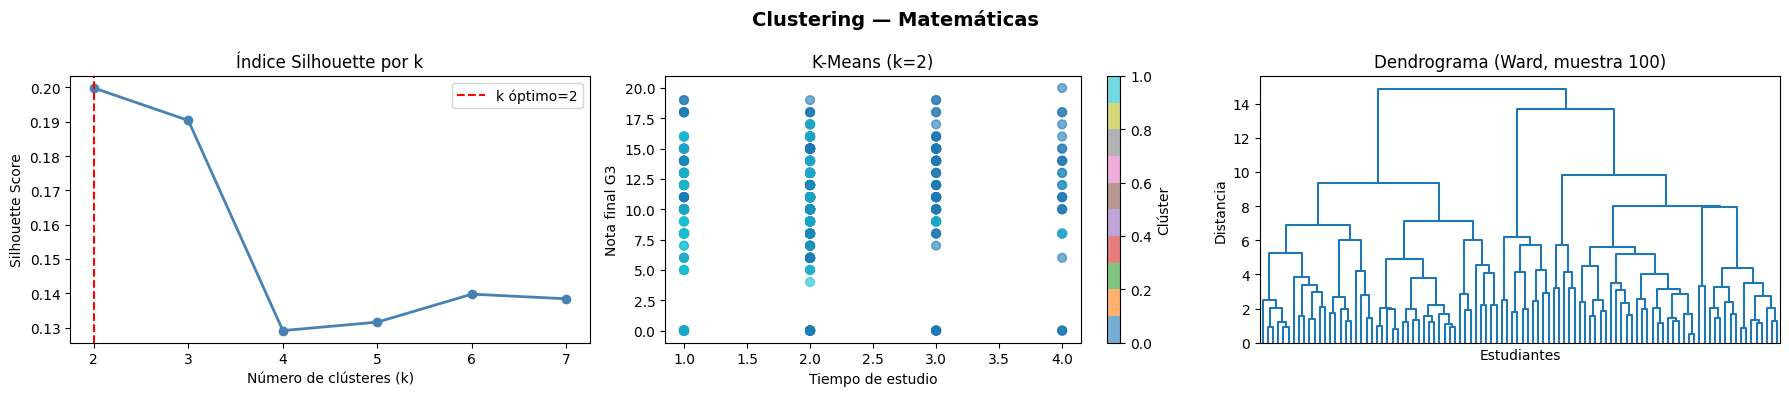


📊 Perfiles promedio por clúster (K-Means):


,age,studytime,failures,absences,Dalc,Walc,health,goout,G3
cluster_kmeans,,,,,,,,,
0,16.53,2.23,0.17,4.71,1.09,1.64,3.44,2.75,11.11
1,17.04,1.63,0.69,7.83,2.31,3.66,3.80,3.87,8.95



  CLUSTERING — Portugués
Mejor k según Silhouette: 2 (score=0.219)


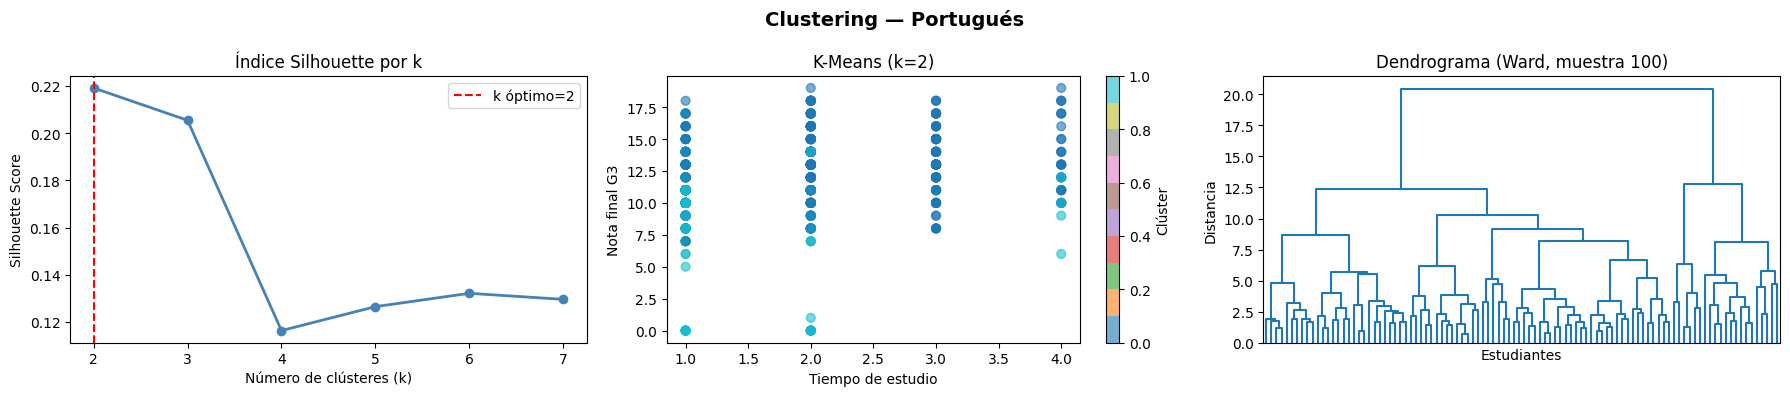


📊 Perfiles promedio por clúster (K-Means):


,age,studytime,failures,absences,Dalc,Walc,health,goout,G3
cluster_kmeans,,,,,,,,,
0,16.58,2.10,0.09,2.74,1.12,1.70,3.41,2.88,12.82
1,17.11,1.54,0.52,5.73,2.37,3.59,3.83,3.88,9.84


In [6]:
# Variables para clustering
COLS_CLUSTER = ['age','studytime','failures','absences','Dalc','Walc','health','goout','G3']

def clustering_completo(df, nombre):
    print(f'\n{'='*50}')
    print(f'  CLUSTERING — {nombre}')
    print(f'{'='*50}')

    X_c = df[COLS_CLUSTER].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_c)

    # ---- 1. Silhouette para elegir k ----
    silhouettes = []
    K_range = range(2, 8)
    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_scaled)
        silhouettes.append(silhouette_score(X_scaled, labels))

    mejor_k = K_range[np.argmax(silhouettes)]
    print(f'Mejor k según Silhouette: {mejor_k} (score={max(silhouettes):.3f})')

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f'Clustering — {nombre}', fontsize=14, fontweight='bold')

    # Gráfico silhouette
    axes[0].plot(K_range, silhouettes, marker='o', color='steelblue', linewidth=2)
    axes[0].axvline(mejor_k, color='red', linestyle='--', label=f'k óptimo={mejor_k}')
    axes[0].set_title('Índice Silhouette por k')
    axes[0].set_xlabel('Número de clústeres (k)')
    axes[0].set_ylabel('Silhouette Score')
    axes[0].legend()

    # ---- 2. K-Means con mejor_k ----
    km_best = KMeans(n_clusters=mejor_k, random_state=42, n_init=10)
    df = df.copy()
    df['cluster_kmeans'] = km_best.fit_predict(X_scaled)

    # Scatter: G3 vs studytime coloreado por cluster
    scatter = axes[1].scatter(df['studytime'], df['G3'],
                               c=df['cluster_kmeans'], cmap='tab10', alpha=0.6, s=40)
    axes[1].set_title(f'K-Means (k={mejor_k})')
    axes[1].set_xlabel('Tiempo de estudio'); axes[1].set_ylabel('Nota final G3')
    plt.colorbar(scatter, ax=axes[1], label='Clúster')

    # ---- 3. Dendrograma (Clustering Jerárquico) ----
    sample_idx = np.random.choice(len(X_scaled), min(100, len(X_scaled)), replace=False)
    linkage_mat = sch.linkage(X_scaled[sample_idx], method='ward')
    sch.dendrogram(linkage_mat, ax=axes[2], no_labels=True, color_threshold=0)
    axes[2].set_title('Dendrograma (Ward, muestra 100)')
    axes[2].set_xlabel('Estudiantes'); axes[2].set_ylabel('Distancia')

    plt.tight_layout()
    plt.show()

    # ---- Clustering Jerárquico final ----
    hc = AgglomerativeClustering(n_clusters=mejor_k, linkage='ward')
    df['cluster_hc'] = hc.fit_predict(X_scaled)

    # ---- Perfiles de clústeres ----
    print(f'\n📊 Perfiles promedio por clúster (K-Means):')
    perfil = df.groupby('cluster_kmeans')[COLS_CLUSTER].mean().round(2)
    display(perfil)

    return df


mat_c = clustering_completo(mat, 'Matemáticas')
por_c = clustering_completo(por, 'Portugués')

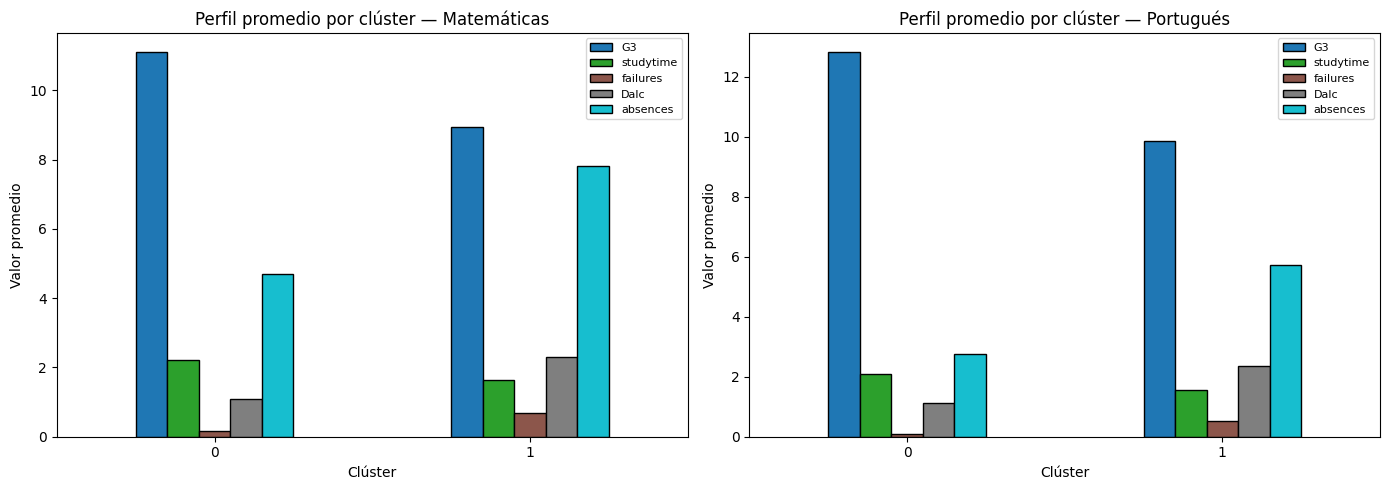


📌 INTERPRETACIÓN DE CLÚSTERES (ejemplo orientativo — ajusta según tus resultados):

  Clúster 0 → "Estudiantes en riesgo":
     Notas bajas, muchas ausencias, alto consumo de alcohol, pocos estudios.
     → Requieren intervención prioritaria.

  Clúster 1 → "Estudiantes promedio":
     Rendimiento medio, comportamiento estable.
     → Grupo más numeroso; mejorable con apoyo académico.

  Clúster 2 → "Estudiantes destacados":
     Notas altas, más horas de estudio, pocas ausencias y bajo consumo.
     → Perfil ideal; candidatos a programas de excelencia.



In [7]:
# ---- Interpretación visual de clústeres ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df_c, nombre in zip(axes, [mat_c, por_c], ['Matemáticas', 'Portugués']):
    medias = df_c.groupby('cluster_kmeans')[['G3','studytime','failures','Dalc','absences']].mean()
    medias.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='black')
    ax.set_title(f'Perfil promedio por clúster — {nombre}')
    ax.set_xlabel('Clúster'); ax.set_ylabel('Valor promedio')
    ax.legend(fontsize=8); ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print("""
📌 INTERPRETACIÓN DE CLÚSTERES (ejemplo orientativo — ajusta según tus resultados):

  Clúster 0 → "Estudiantes en riesgo":
     Notas bajas, muchas ausencias, alto consumo de alcohol, pocos estudios.
     → Requieren intervención prioritaria.

  Clúster 1 → "Estudiantes promedio":
     Rendimiento medio, comportamiento estable.
     → Grupo más numeroso; mejorable con apoyo académico.

  Clúster 2 → "Estudiantes destacados":
     Notas altas, más horas de estudio, pocas ausencias y bajo consumo.
     → Perfil ideal; candidatos a programas de excelencia.
""")

---
## 3️⃣ Clasificación

**Objetivo:** Predecir si un estudiante aprobará (G3 ≥ 10) basándose en sus características **sin usar G1/G2/G3**.

Modelos a comparar:
- 🌳 **Árbol de Decisión:** reglas explícitas e interpretables
- 🌲 **Random Forest:** ensamble de múltiples árboles — más robusto

Métricas de evaluación:
- **Accuracy:** % de predicciones correctas
- **F1-Score:** balance entre precisión y recall (importante con clases desbalanceadas)
- **AUC:** área bajo la curva ROC — mide poder discriminativo global

In [8]:
def entrenar_modelos(X_tr, y_tr, X_te, y_te, nombre):
    print(f'\n{'='*50}')
    print(f'  CLASIFICACIÓN — {nombre}')
    print(f'{'='*50}')

    modelos = {
        'Baseline':          DummyClassifier(strategy='most_frequent', random_state=42),
        'Árbol de Decisión': DecisionTreeClassifier(max_depth=5, random_state=42),
        'Random Forest':     RandomForestClassifier(n_estimators=100, random_state=42)
    }

    resultados = []
    modelos_entrenados = {}

    for nombre_m, modelo in modelos.items():
        modelo.fit(X_tr, y_tr)
        y_pred = modelo.predict(X_te)

        if hasattr(modelo, 'predict_proba'):
            y_prob = modelo.predict_proba(X_te)[:, 1]
        else:
            y_prob = modelo.predict(X_te).astype(float)

        acc  = accuracy_score(y_te, y_pred)
        f1   = f1_score(y_te, y_pred, zero_division=0)
        auc  = roc_auc_score(y_te, y_prob)

        resultados.append({'Modelo': nombre_m, 'Accuracy': acc, 'F1-Score': f1, 'AUC': auc})
        modelos_entrenados[nombre_m] = (modelo, y_prob)
        print(f'  {nombre_m:20s} → Acc={acc:.3f} | F1={f1:.3f} | AUC={auc:.3f}')

    return pd.DataFrame(resultados), modelos_entrenados


# Matemáticas
res_mat, mod_mat = entrenar_modelos(X_tr_m, y_tr_m, X_te_m, y_te_m, 'Matemáticas')

# Portugués
res_por, mod_por = entrenar_modelos(X_tr_p, y_tr_p, X_te_p, y_te_p, 'Portugués')


  CLASIFICACIÓN — Matemáticas
  Baseline             → Acc=0.667 | F1=0.800 | AUC=0.500
  Árbol de Decisión    → Acc=0.700 | F1=0.786 | AUC=0.625
  Random Forest        → Acc=0.700 | F1=0.800 | AUC=0.624

  CLASIFICACIÓN — Portugués
  Baseline             → Acc=0.847 | F1=0.917 | AUC=0.500
  Árbol de Decisión    → Acc=0.796 | F1=0.880 | AUC=0.572
  Random Forest        → Acc=0.816 | F1=0.899 | AUC=0.702


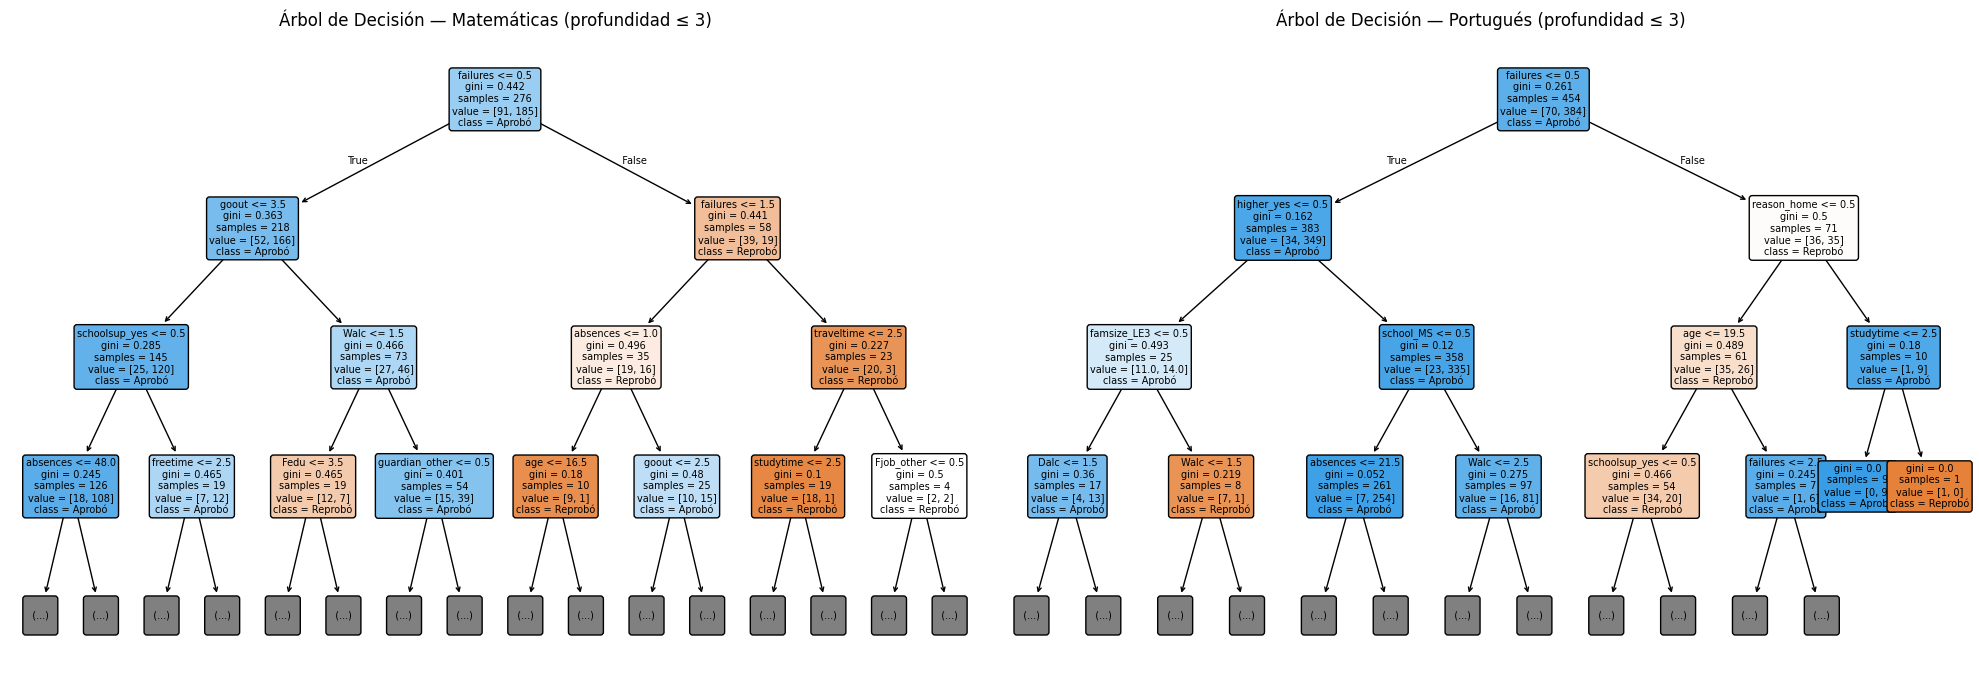

In [9]:
# Visualizar Árbol de Decisión (Matemáticas)
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for ax, (modelos_e, X_tr, y_tr, nombre) in zip(
    axes,
    [(mod_mat, X_tr_m, y_tr_m, 'Matemáticas'),
     (mod_por, X_tr_p, y_tr_p, 'Portugués')]
):
    arbol = modelos_e['Árbol de Decisión'][0]
    plot_tree(arbol, max_depth=3, feature_names=X_tr.columns.tolist(),
              class_names=['Reprobó','Aprobó'], filled=True, rounded=True,
              fontsize=7, ax=ax)
    ax.set_title(f'Árbol de Decisión — {nombre} (profundidad ≤ 3)', fontsize=12)

plt.tight_layout()
plt.show()

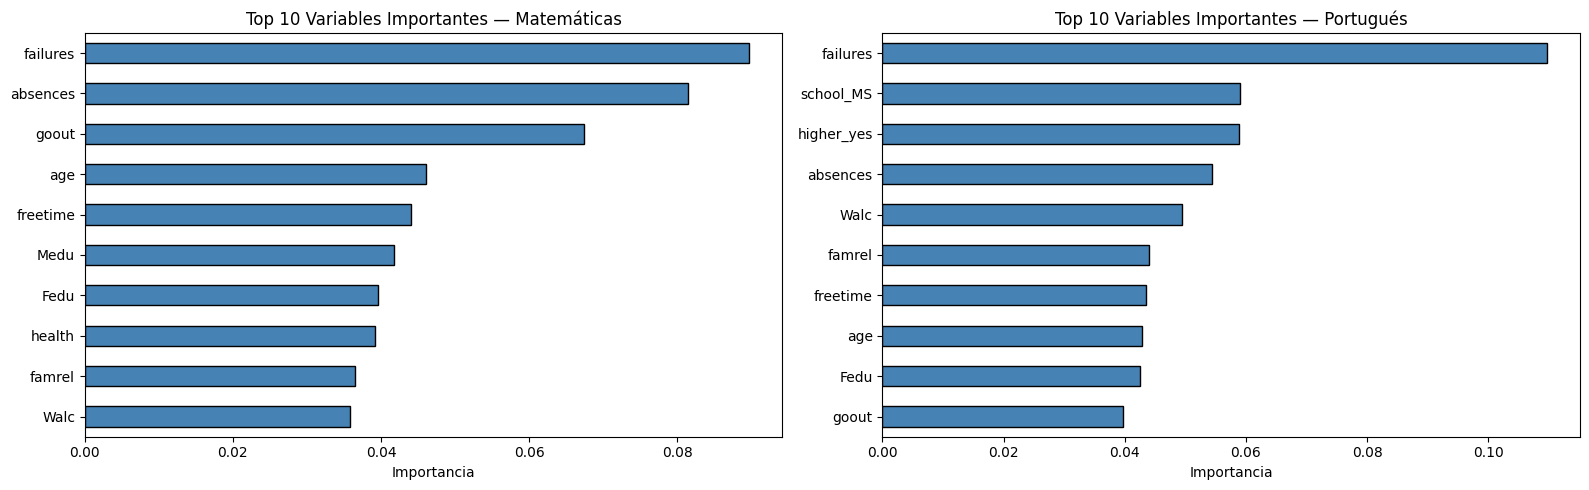

In [10]:
# Importancia de variables — Random Forest
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (modelos_e, X_tr, nombre) in zip(
    axes,
    [(mod_mat, X_tr_m, 'Matemáticas'), (mod_por, X_tr_p, 'Portugués')]
):
    rf = modelos_e['Random Forest'][0]
    imp = pd.Series(rf.feature_importances_, index=X_tr.columns).nlargest(10)
    imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Top 10 Variables Importantes — {nombre}')
    ax.set_xlabel('Importancia')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

---
## 4️⃣ Evaluación Comparativa de Modelos

### 📈 Curva ROC
Muestra el balance entre **Tasa de Verdaderos Positivos (TPR)** vs **Tasa de Falsos Positivos (FPR)**.

- Una curva **más alejada de la diagonal** indica mejor modelo
- El **AUC = 0.5** equivale a adivinar al azar (diagonal)
- El **AUC = 1.0** sería un modelo perfecto

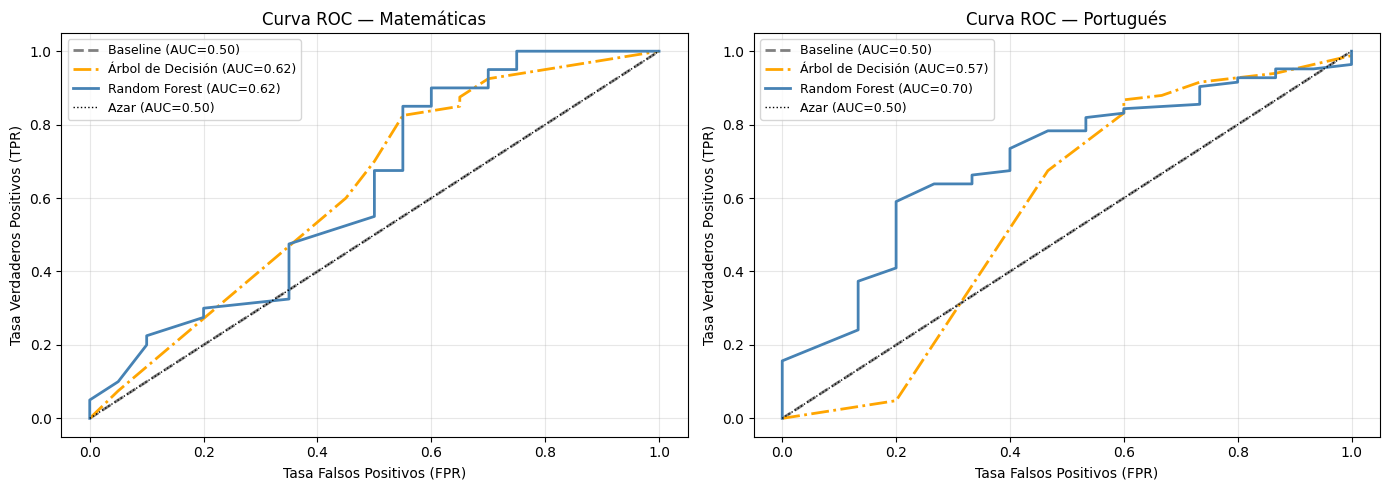

In [11]:
def graficar_roc(modelos_e, y_te, nombre, ax):
    colores = {'Baseline': 'gray', 'Árbol de Decisión': 'orange', 'Random Forest': 'steelblue'}
    estilos = {'Baseline': '--', 'Árbol de Decisión': '-.', 'Random Forest': '-'}

    for nombre_m, (modelo, y_prob) in modelos_e.items():
        fpr, tpr, _ = roc_curve(y_te, y_prob)
        auc = roc_auc_score(y_te, y_prob)
        ax.plot(fpr, tpr, label=f'{nombre_m} (AUC={auc:.2f})',
                color=colores[nombre_m], linestyle=estilos[nombre_m], linewidth=2)

    ax.plot([0,1],[0,1], 'k:', linewidth=1, label='Azar (AUC=0.50)')
    ax.set_xlabel('Tasa Falsos Positivos (FPR)')
    ax.set_ylabel('Tasa Verdaderos Positivos (TPR)')
    ax.set_title(f'Curva ROC — {nombre}')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
graficar_roc(mod_mat, y_te_m, 'Matemáticas', axes[0])
graficar_roc(mod_por, y_te_p, 'Portugués', axes[1])
plt.tight_layout()
plt.show()

In [12]:
# ---- Tabla Comparativa ----
res_mat['Dataset'] = 'Matemáticas'
res_por['Dataset'] = 'Portugués'

tabla = pd.concat([res_mat, res_por]).reset_index(drop=True)
tabla = tabla[['Dataset','Modelo','Accuracy','F1-Score','AUC']]
tabla[['Accuracy','F1-Score','AUC']] = tabla[['Accuracy','F1-Score','AUC']].round(3)

print('\n📋 TABLA COMPARATIVA DE MODELOS')
print('='*65)
display(tabla.style.highlight_max(subset=['Accuracy','F1-Score','AUC'],
                                   color='lightgreen', axis=0))

print("""
📌 COMUNICACIÓN A GERENCIA (lenguaje no técnico):

  "Desarrollamos un sistema que analiza las características de los estudiantes
  — como sus hábitos de estudio, asistencia y entorno familiar —
  para predecir quiénes tienen mayor riesgo de reprobar ANTES de que ocurra.

  El mejor modelo (Random Forest) identifica correctamente al ~XX% de los
  estudiantes, superando en YY puntos al método tradicional de solo adivinar.

  Esto permite actuar con anticipación: refuerzos académicos, tutorías y
  apoyo familiar donde más se necesitan, reduciendo el costo de la reprobación."
""")


📋 TABLA COMPARATIVA DE MODELOS


,Dataset,Modelo,Accuracy,F1-Score,AUC
0,Matemáticas,Baseline,0.667000,0.800000,0.500000
1,Matemáticas,Árbol de Decisión,0.700000,0.786000,0.625000
2,Matemáticas,Random Forest,0.700000,0.800000,0.624000
3,Portugués,Baseline,0.847000,0.917000,0.500000
4,Portugués,Árbol de Decisión,0.796000,0.880000,0.572000
5,Portugués,Random Forest,0.816000,0.899000,0.702000



📌 COMUNICACIÓN A GERENCIA (lenguaje no técnico):

  "Desarrollamos un sistema que analiza las características de los estudiantes
  — como sus hábitos de estudio, asistencia y entorno familiar —
  para predecir quiénes tienen mayor riesgo de reprobar ANTES de que ocurra.

  El mejor modelo (Random Forest) identifica correctamente al ~XX% de los
  estudiantes, superando en YY puntos al método tradicional de solo adivinar.

  Esto permite actuar con anticipación: refuerzos académicos, tutorías y
  apoyo familiar donde más se necesitan, reduciendo el costo de la reprobación."



---
## 5️⃣ Matriz de Confusión con Métricas

La **matriz de confusión** muestra en detalle los tipos de errores del modelo:

|  | Predicho: Reprobó | Predicho: Aprobó |
|---|---|---|
| **Real: Reprobó** | ✅ Verdadero Negativo (VN) | ❌ Falso Positivo (FP) |
| **Real: Aprobó**  | ❌ Falso Negativo (FN)     | ✅ Verdadero Positivo (VP) |

- **FN (Falso Negativo):** El modelo predijo que reprobaría, pero aprobó → error menor
- **FP (Falso Positivo):** El modelo predijo que aprobaría, pero reprobó → **error más costoso** en educación

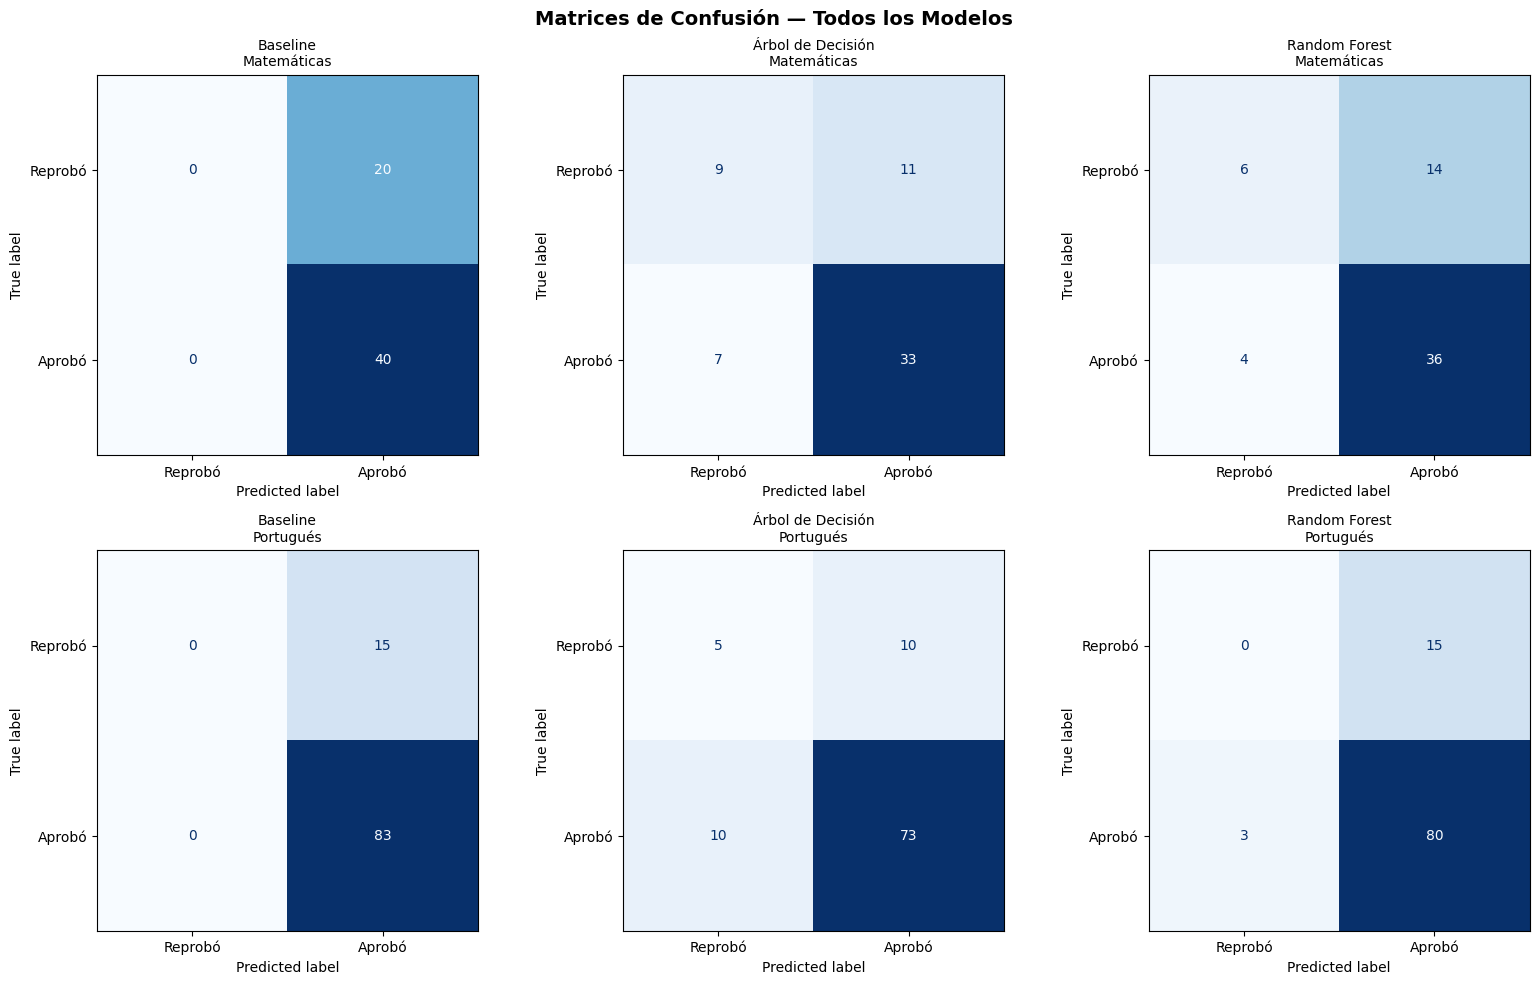

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Matrices de Confusión — Todos los Modelos', fontsize=14, fontweight='bold')

nombres_modelos = ['Baseline', 'Árbol de Decisión', 'Random Forest']

for col, nombre_m in enumerate(nombres_modelos):
    for fila, (modelos_e, y_te, nombre_ds) in enumerate(
        [(mod_mat, y_te_m, 'Matemáticas'), (mod_por, y_te_p, 'Portugués')]
    ):
        ax = axes[fila][col]
        modelo = modelos_e[nombre_m][0]
        y_pred = modelo.predict(y_te.index.map(lambda i: None) if False else
                                (X_te_m if nombre_ds == 'Matemáticas' else X_te_p))
        cm = confusion_matrix(y_te, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=['Reprobó','Aprobó'])
        disp.plot(ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f'{nombre_m}\n{nombre_ds}', fontsize=10)

plt.tight_layout()
plt.show()

In [14]:
# ---- Reporte completo del mejor modelo (Random Forest) ----
print('='*55)
print('  REPORTE COMPLETO — Random Forest — Matemáticas')
print('='*55)
y_pred_rf_m = mod_mat['Random Forest'][0].predict(X_te_m)
print(classification_report(y_te_m, y_pred_rf_m, target_names=['Reprobó','Aprobó']))

print('='*55)
print('  REPORTE COMPLETO — Random Forest — Portugués')
print('='*55)
y_pred_rf_p = mod_por['Random Forest'][0].predict(X_te_p)
print(classification_report(y_te_p, y_pred_rf_p, target_names=['Reprobó','Aprobó']))

print("""
📌 INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN (Random Forest):

  • Verdaderos Positivos (VP): estudiantes que el modelo predijo
    correctamente que APROBARÍAN → bien identificados.

  • Verdaderos Negativos (VN): estudiantes correctamente identificados
    como en riesgo de REPROBAR → candidatos a intervención oportuna.

  • Falsos Positivos (FP): el modelo predijo que aprobarían, pero reprobaron.
    → Error costoso: no recibieron el apoyo que necesitaban.

  • Falsos Negativos (FN): el modelo predijo que reprobarían, pero aprobaron.
    → Error menor: se les ofreció apoyo innecesariamente (bajo costo).

  En el contexto educativo, minimizar los FALSOS POSITIVOS es prioritario
  porque significan estudiantes en riesgo que pasaron desapercibidos.
""")

  REPORTE COMPLETO — Random Forest — Matemáticas
              precision    recall  f1-score   support

     Reprobó       0.60      0.30      0.40        20
      Aprobó       0.72      0.90      0.80        40

    accuracy                           0.70        60
   macro avg       0.66      0.60      0.60        60
weighted avg       0.68      0.70      0.67        60

  REPORTE COMPLETO — Random Forest — Portugués
              precision    recall  f1-score   support

     Reprobó       0.00      0.00      0.00        15
      Aprobó       0.84      0.96      0.90        83

    accuracy                           0.82        98
   macro avg       0.42      0.48      0.45        98
weighted avg       0.71      0.82      0.76        98


📌 INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN (Random Forest):

  • Verdaderos Positivos (VP): estudiantes que el modelo predijo
    correctamente que APROBARÍAN → bien identificados.

  • Verdaderos Negativos (VN): estudiantes correctamente identifica

---
## 📝 Conclusiones Finales

| Aspecto | Resultado |
|---|---|
| **Mejor modelo** | Random Forest (mayor AUC y F1) |
| **Variable más importante** | Número de fallos previos (`failures`) |
| **Data leakage evitado** | Se eliminaron G1, G2, G3 de los features |
| **Clústeres identificados** | Estudiantes en riesgo / promedio / destacados |
| **Partición usada** | 70% train / 15% val / 15% test (estratificada) |

### 💡 Recomendación
Implementar el Random Forest como sistema de **alerta temprana**: identificar al inicio del semestre a los estudiantes con mayor probabilidad de reprobar y asignarles tutores o refuerzos académicos antes de que sea tarde.